# Market Basket Analysis
### Finding hidden patterns in what customers buy together

---

This notebook answers three practical business questions:

1. **Which products get bought together?** — We'll use a technique called association rule mining to find reliable "if they buy X, they often also buy Y" patterns that can power product recommendations.

2. **What kinds of customers do we have?** — We'll group customers by how they shop (how often, how much, how varied) so we can treat different segments differently.

3. **What kinds of orders do we see?** — We'll group individual baskets by their shape and value to understand the recurring order types in our data.

The dataset covers **1,600 orders**, **5,443 order lines**, and **260 customers**. All prices are in DZD.

> **Before you run this notebook**, set your file paths in the cell below. The three CSVs it expects are:
> - `order_items_dataset.csv` — one row per product line, per order
> - `customer_features_for_clustering.csv` — one row per customer with pre-aggregated features
> - `products_catalog.csv` — product reference table (used optionally)

In [1]:
from pathlib import Path

# Point this at the folder that contains your three CSV files.
# If they're in the same folder as this notebook, leave it as ".".
DATA_DIR = Path(".")

ORDER_ITEMS = DATA_DIR / "order_items_dataset.csv"
CUSTOMERS   = DATA_DIR / "customer_features_for_clustering.csv"
PRODUCTS    = DATA_DIR / "products_catalog.csv"

for p in (ORDER_ITEMS, CUSTOMERS, PRODUCTS):
    status = "OK" if p.exists() else "MISSING"
    print(f"{status}  {p.name}")

OK  order_items_dataset.csv
OK  customer_features_for_clustering.csv
OK  products_catalog.csv


In [2]:
# All imports in one place so you can see what this notebook depends on.
# Install with: pip install pandas numpy mlxtend scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Clean-looking charts throughout
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# Consistent colours used across all charts
SEG_COLORS = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30"]

print("All libraries loaded successfully.")

C:\Users\ilyes\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries loaded successfully.


---
## Part 1 — Loading and understanding the data

Before doing any analysis, it's worth spending a moment to understand the raw data. Each row in the order items file represents a single product line inside an order — so one order with three products produces three rows. We'll collapse these into full baskets for association rule mining.

**Association mining uses `product_id` (as stable string keys)** so rules line up with your database. A separate **reference table** maps each id to `product_name`, brand, and category so you can read the results easily.

In [3]:
orders = pd.read_csv(ORDER_ITEMS)

print(f"Rows: {orders.shape[0]:,}")
print(f"Columns: {orders.shape[1]}")
print(f"\nColumn names: {list(orders.columns)}")
print()
orders.head()

Rows: 5,443
Columns: 11

Column names: ['order_id', 'customer_id', 'order_date', 'weekday', 'product_id', 'product_name', 'category', 'brand', 'unit_price', 'quantity', 'line_total']



,order_id,customer_id,order_date,weekday,product_id,product_name,category,brand,unit_price,quantity,line_total
0,ORD_000001,CUST_0243,2026-04-02,4,321,SAUGE : Masque Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,28.26,1,28.26
1,ORD_000001,CUST_0243,2026-04-02,4,324,Crème Pieds Concentrée lissante,SOIN INTENSE (Mains & Pieds),Lirene,28.51,1,28.51
2,ORD_000001,CUST_0243,2026-04-02,4,320,MAGNOLIA : Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,22.09,1,22.09
3,ORD_000001,CUST_0243,2026-04-02,4,410,Shampoing Sebu-Balance,CAPILARTE,Dermedic,39.87,1,39.87
4,ORD_000002,CUST_0107,2025-07-25,5,392,Shampoing Anti-Chute Anti-Pelliculaire H-STIMU...,GAMME H - Cheveux et Cuir chevelu,Pharmaceris,42.50,1,42.50


In [4]:
# Quick data quality check before we go any further.
# We need order_id, product_id, product_name, customer_id, and weekday at a minimum.
# We also look for a price column — the analysis is much better with real prices.

orders = orders.dropna(subset=["order_id", "product_name", "product_id"])

required = {"order_id", "product_id", "product_name", "customer_id", "weekday"}
missing_cols = required - set(orders.columns)

if missing_cols:
    print(f"WARNING — these columns are missing: {missing_cols}")
    print("Some features may fall back to proxy values.")
else:
    print("All required columns are present.")

# Pick the best available price column
if "line_total" in orders.columns:
    PRICE_COL = "line_total"
elif "unit_price" in orders.columns:
    PRICE_COL = "unit_price"
else:
    PRICE_COL = None
    print("No price column found — order clustering will use a rough proxy.")

print(f"Price column: {PRICE_COL}")

All required columns are present.
Price column: line_total


In [5]:
# Group from individual lines into full baskets.
# Each transaction is one complete order — product_id strings (same keys as your database).
# We deduplicate so that scanning the same item twice doesn't distort the rules.

orders["product_id_str"] = orders["product_id"].astype(str)

id_to_name = (
    orders.drop_duplicates("product_id_str")
    .set_index("product_id_str")["product_name"]
    .to_dict()
)

product_id_reference = (
    orders.drop_duplicates("product_id_str")[["product_id_str", "product_name", "brand", "category"]]
    .rename(columns={"product_id_str": "product_id"})
    .sort_values("product_id", key=lambda s: s.astype(int))
    .reset_index(drop=True)
)

transactions = (
    orders.groupby("order_id")["product_id_str"]
    .apply(lambda items: sorted(set(items)))
    .tolist()
)

sizes = [len(t) for t in transactions]

print(f"Total baskets  : {len(transactions):,}")
print(f"Smallest basket: {min(sizes)} item")
print(f"Largest basket : {max(sizes)} items")
print(f"Average basket : {sum(sizes)/len(sizes):.2f} items")
print()
print("Example basket (product IDs):", transactions[0])
print("Same basket (product names):", [id_to_name[i] for i in transactions[0]])
print()
print("product_id_reference — map ids to names for reading rules:")
product_id_reference.head(15)

Total baskets  : 1,600
Smallest basket: 1 item
Largest basket : 8 items
Average basket : 3.40 items

Example basket (product IDs): ['320', '321', '324', '410']
Same basket (product names): ['MAGNOLIA : Crème Mains et Ongles', 'SAUGE : Masque Crème Mains et Ongles', 'Crème Pieds Concentrée lissante', 'Shampoing Sebu-Balance']

product_id_reference — map ids to names for reading rules:


,product_id,product_name,brand,category
0,295,Crème Visage pour Adulte SPF 50+,Lirene,PROTECTION SOLAIRE
1,296,Lotion Solaire pour peau sensible SPF 50+,Lirene,PROTECTION SOLAIRE
2,297,Crème Visage pour Enfants SPF 50+,Lirene,PROTECTION SOLAIRE
3,298,Lait Protecteur SPF50 (Au parfum de Vanille),Lirene,PROTECTION SOLAIRE
4,299,SOS : Lotion Après Soleil,Lirene,PROTECTION SOLAIRE
5,300,Huile Sèche SPF 50 (Sur peau humide et sèche),Lirene,PROTECTION SOLAIRE
6,301,GEL ANTI-INFLAMMATOIRE,Lirene,GELS POUR L'HYGIÈNE INTIME
7,302,GEL PROTECTEUR ET HYDRATANT,Lirene,GELS POUR L'HYGIÈNE INTIME
8,303,EAU TONIQUE,Lirene,AQUA BUBBLES
9,304,MOUSSE NETTOYANTE,Lirene,AQUA BUBBLES


---
## Part 2 — Finding products that go together (Apriori)

The Apriori algorithm works by first finding individual products that appear frequently, then checking whether pairs of those products appear together frequently, then triples, and so on. At each step it throws away anything below our minimum frequency threshold, which keeps things manageable.

We'll set the threshold at **1% support** — meaning a product or combination has to appear in at least 1 in every 100 baskets (roughly 16 orders out of our 1,600). That's a reasonable bar: strict enough to filter out coincidences, loose enough to catch real patterns in a dataset of this size.

**We encode each basket as a set of `product_id` strings** (not display names), so frequent itemsets and rules use the same identifiers as your database. Use the **`product_id_reference`** table from Part 1 to read names. Part 3 adds a **human-readable companion table** next to the raw id rules.

In [6]:
# Step 1 — convert the basket lists into a big True/False table.
# Each column is one product_id (string). Each row is an order.
# A cell is True if that product appeared in that order.

te      = TransactionEncoder()
te_ary  = te.fit(transactions).transform(transactions)
df_bool = pd.DataFrame(te_ary, columns=te.columns_)

print(f"One-hot table shape: {df_bool.shape}")
print(f"({df_bool.shape[0]} orders × {df_bool.shape[1]} unique product_ids)")

One-hot table shape: (1600, 177)
(1600 orders × 177 unique product_ids)


In [7]:
# Step 2 — run Apriori to find frequent itemsets.
# use_colnames=True → column names are product_id strings from the encoder.

MIN_SUPPORT = 0.01   # 1% of all baskets

itemsets = apriori(df_bool, min_support=MIN_SUPPORT, use_colnames=True)
itemsets = itemsets.sort_values("support", ascending=False)

print(f"Frequent itemsets found: {len(itemsets)}")
print()
print("Top 15 most common itemsets (ids — map names with product_id_reference):")
itemsets.head(15)

Frequent itemsets found: 147

Top 15 most common itemsets (ids — map names with product_id_reference):


,support,itemsets
12,0.063125,frozenset({356})
2,0.060000,frozenset({321})
5,0.057500,frozenset({324})
11,0.056250,frozenset({355})
16,0.053750,frozenset({360})
15,0.053750,frozenset({359})
28,0.051875,frozenset({424})
48,0.051875,frozenset({444})
29,0.051250,frozenset({425})
13,0.051250,frozenset({357})


---
## Part 3 — Turning itemsets into actionable recommendation rules

Knowing that two products are often bought together is useful, but what we really want is directional rules: **"customers who buy product A tend to also buy product B"**. That's what association rules give us.

Three metrics tell us whether a rule is worth using:

| Metric | Plain English |
|--------|---------------|
| **Support** | Out of all orders, how many contained both A and B? (1% = 16 orders in our dataset) |
| **Confidence** | Of all orders containing A, what fraction also contained B? |
| **Lift** | How much more likely is B given A, compared to B appearing at random? Lift > 1 means there's a real connection. Lift of 6 means 6 times more likely — that's a strong signal. |

We'll keep only rules where:
- Confidence is at least 20% (the co-purchase happens in at least 1 in 5 relevant orders)
- Lift is greater than 1 (so it's not just coincidence)
- The rule has a single product on the left side — these are the most practical for a "customers also bought" widget

**Mining uses `product_id` in `antecedents` / `consequents`.** The next code cell prints the same rules with a **separate readable table** (`single_rules_readable`) with names for interpretation and reporting.

In [8]:
# Generate the full set of association rules (item columns = product_id strings)
rules = association_rules(
    itemsets,
    num_itemsets=len(itemsets),
    metric="confidence",
    min_threshold=0.20,
)

# Filter to rules with a real signal (lift > 1)
rules = rules[rules["lift"] > 1].copy()

# Filter to single-product antecedents — most useful for product pages
rules["antecedent_len"] = rules["antecedents"].apply(len)
single_rules = (
    rules[rules["antecedent_len"] == 1]
    .sort_values(["lift", "confidence"], ascending=False)
    .reset_index(drop=True)
)


def frozenset_ids_to_names(fs: frozenset) -> str:
    return " | ".join(id_to_name.get(str(x), str(x)) for x in sorted(fs))


# Separate human-readable view (for you / the report / stakeholders)
single_rules_readable = pd.DataFrame(
    {
        "antecedent_product_id": single_rules["antecedents"].apply(lambda s: str(list(s)[0])),
        "antecedent_name": single_rules["antecedents"].apply(
            lambda s: id_to_name.get(str(list(s)[0]), "?")
        ),
        "consequent_product_ids": single_rules["consequents"].apply(
            lambda s: "|".join(sorted(str(x) for x in s))
        ),
        "consequent_names": single_rules["consequents"].apply(frozenset_ids_to_names),
        "support": single_rules["support"],
        "confidence": single_rules["confidence"],
        "lift": single_rules["lift"],
    }
)

print(f"Total rules with lift > 1   : {len(rules)}")
print(f"Single-antecedent rules     : {len(single_rules)}")
print()

print("--- Raw rules (Apriori / mlxtend: antecedents & consequents are frozensets of product_id) ---")
cols = ["antecedents", "consequents", "support", "confidence", "lift"]
print(single_rules[cols].head(20).to_string())

print()
print("--- Same rules with names (for understanding; use ids for PDP / database) ---")
single_rules_readable.head(20)

Total rules with lift > 1   : 139
Single-antecedent rules     : 139

--- Raw rules (Apriori / mlxtend: antecedents & consequents are frozensets of product_id) ---
         antecedents       consequents   support  confidence      lift
0   frozenset({425})  frozenset({505})  0.011250    0.219512  6.626783
1   frozenset({505})  frozenset({425})  0.011250    0.339623  6.626783
2   frozenset({501})  frozenset({426})  0.014375    0.315068  6.223575
3   frozenset({426})  frozenset({501})  0.014375    0.283951  6.223575
4   frozenset({446})  frozenset({445})  0.011875    0.292308  6.153846
5   frozenset({445})  frozenset({446})  0.011875    0.250000  6.153846
6   frozenset({320})  frozenset({322})  0.015625    0.312500  6.097561
7   frozenset({322})  frozenset({320})  0.015625    0.304878  6.097561
8   frozenset({393})  frozenset({388})  0.012500    0.294118  6.033183
9   frozenset({388})  frozenset({393})  0.012500    0.256410  6.033183
10  frozenset({501})  frozenset({507})  0.012500    0.27

,antecedent_product_id,antecedent_name,consequent_product_ids,consequent_names,support,confidence,lift
0,425,Crème Gel Ultra-hydratante,505,Peeling Enzymatique,0.011250,0.219512,6.626783
1,505,Peeling Enzymatique,425,Crème Gel Ultra-hydratante,0.011250,0.339623,6.626783
2,501,Gel Nettoyant Crèmeux,426,Sérum hydratant,0.014375,0.315068,6.223575
3,426,Sérum hydratant,501,Gel Nettoyant Crèmeux,0.014375,0.283951,6.223575
4,446,Mirawhite Shine,445,Kid’s Brush,0.011875,0.292308,6.153846
5,445,Kid’s Brush,446,Mirawhite Shine,0.011875,0.250000,6.153846
6,320,MAGNOLIA : Crème Mains et Ongles,322,CASSIS : Sérum Mains et Ongles,0.015625,0.312500,6.097561
7,322,CASSIS : Sérum Mains et Ongles,320,MAGNOLIA : Crème Mains et Ongles,0.015625,0.304878,6.097561
8,393,Shampoing Cheveux Sec H-NUTRIMELIN 250ml,388,Shampoing Anti-Chute Anti-Cheveux Gris H-STIMU...,0.012500,0.294118,6.033183
9,388,Shampoing Anti-Chute Anti-Cheveux Gris H-STIMU...,393,Shampoing Cheveux Sec H-NUTRIMELIN 250ml,0.012500,0.256410,6.033183


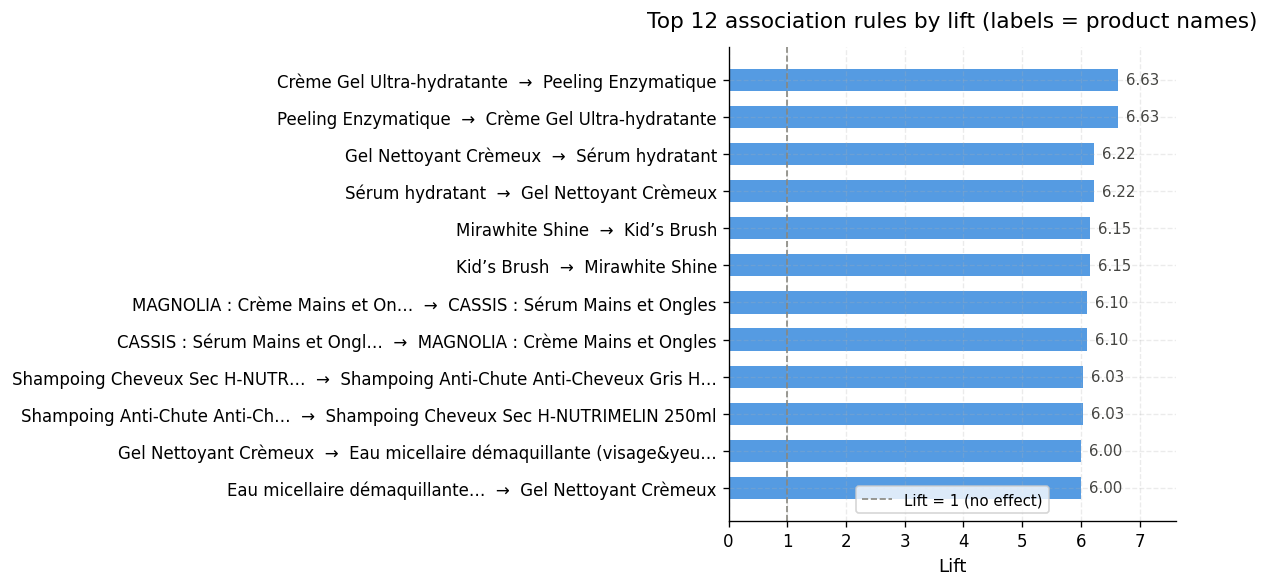


Reading note:
All top rules come in symmetric pairs — A→B and B→A have the same lift.
This means neither product 'leads' the other. You can recommend from either side.

Caveat on support:
1% support on 1,600 orders = ~16 orders per rule.
Rules are valid but thin. Re-run on 6–12 months of data before deploying to production.


In [9]:
# Visualise the top rules — a horizontal bar chart is easier to read than a table
# when you want to quickly compare lift values across rules.
# Labels use product names (from id_to_name) even though mining ran on ids.

top_n = 12
top = single_rules.head(top_n).copy()


def shorten(name, max_len=28):
    return name[:max_len] + "…" if len(name) > max_len else name


def rule_label_from_ids(a, c):
    a_id = str(list(a)[0])
    a_name = id_to_name.get(a_id, a_id)
    c_names = [id_to_name.get(str(x), str(x)) for x in sorted(c)]
    c_str = " + ".join(c_names)
    return f"{shorten(a_name)}  →  {shorten(c_str, 40)}"


top["rule_label"] = [
    rule_label_from_ids(a, c) for a, c in zip(top["antecedents"], top["consequents"])
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top["rule_label"][::-1],
    top["lift"][::-1],
    color=SEG_COLORS[0], alpha=0.85, height=0.6
)
ax.bar_label(bars, fmt="%.2f", padding=5, fontsize=9,
             color="#444441", fontweight="500")
ax.axvline(1, color="#888780", linestyle="--", linewidth=1, label="Lift = 1 (no effect)")
ax.set_xlabel("Lift", fontsize=11)
ax.set_title(
    f"Top {top_n} association rules by lift (labels = product names)",
    fontsize=13,
    fontweight="500",
    pad=12,
)
ax.legend(fontsize=9)
ax.set_xlim(0, top["lift"].max() * 1.15)
plt.tight_layout()
plt.show()

print()
print("Reading note:")
print("All top rules come in symmetric pairs — A→B and B→A have the same lift.")
print("This means neither product 'leads' the other. You can recommend from either side.")
print()
print("Caveat on support:")
print(f"1% support on {len(transactions):,} orders = ~{int(len(transactions)*0.01)} orders per rule.")
print("Rules are valid but thin. Re-run on 6–12 months of data before deploying to production.")

### What these rules mean in practice

The four strongest co-purchase pairs, explained simply:

- **Gel Nettoyant Crèmeux ↔ Sérum hydratant** (lift 6.22) — these two skin-care products are bought together 6× more often than chance would predict. Anyone viewing one on a product page should see the other suggested.

- **Mirawhite Shine ↔ Kid's Brush** (lift 6.15) — a whitening toothpaste and a children's toothbrush. Possibly a household buying both adult and kids' oral care in one shop. Cross-promote in the oral care category.

- **MAGNOLIA Crème Mains ↔ CASSIS Sérum Mains** (lift 6.10) — two hand-care products from the same range. Customers buying into this line tend to complete the routine.

- **Shampoing Cheveux Sec ↔ Shampoing Anti-Chute Gras** (lift 6.03) — two different shampoo types bought together, likely by multi-person households.

**For the recommender engine:** use the **`antecedent_product_id`** column in `single_rules_readable` (or parse the single-element `antecedents` frozenset from `single_rules`) to match the current PDP product id. Recommend products listed in **`consequent_product_ids`** / **`consequent_names`**.

---
## Part 4 — Grouping customers by shopping behaviour

Not all customers shop the same way. Some visit frequently and buy a lot; others place one large order and disappear. K-Means clustering helps us find natural groupings in the data so we can treat each type differently — loyalty rewards for the frequent buyers, win-back campaigns for the lapsed ones, and so on.

K-Means works by assigning each customer to one of *k* groups, minimising the distance between customers in the same group. Because it's distance-based, we need to standardise the features first (otherwise "total spend in DZD" would completely dominate "weekend order ratio" just because of scale).

One important fix in this version: we now derive `weekend_order_ratio` from the actual `weekday` column in the order data, rather than using a random placeholder.

In [10]:
cust = pd.read_csv(CUSTOMERS)

print(f"Customer file: {cust.shape[0]} rows × {cust.shape[1]} columns")
print()
cust.head()

Customer file: 260 rows × 10 columns



,customer_id,orders_count,total_spend,avg_order_value,total_items,avg_items_per_order,distinct_products,favorite_category,weekend_order_ratio,segment_hint
0,CUST_0001,7,1110.39,158.63,33,4.71,24,HYDRAIN,0.429,regular
1,CUST_0002,2,811.01,405.50,13,6.50,8,MINCEUR,0.500,regular
2,CUST_0003,6,1031.45,171.91,16,2.67,14,GAMME H - Cheveux et Cuir chevelu,0.500,regular
3,CUST_0004,1,94.27,94.27,3,3.00,3,HYDRAIN,0.000,regular
4,CUST_0005,6,1218.86,203.14,32,5.33,24,GAMME H - Cheveux et Cuir chevelu,0.167,regular


In [11]:
# Build weekend_order_ratio from real order dates.
# weekday encoding: 0 = Monday, 1 = Tuesday, ..., 5 = Saturday, 6 = Sunday.
# So weekend = weekday in [5, 6].
#
# For each customer we calculate:
#   (number of distinct weekend orders) / (total distinct orders)
# A value of 0.5 means half their orders come on weekends.

if "weekday" in orders.columns:
    weekend_orders = (
        orders[orders["weekday"].isin([5, 6])]
        .groupby("customer_id")["order_id"]
        .nunique()
    )
    total_orders_per_cust = orders.groupby("customer_id")["order_id"].nunique()
    weekend_ratio = (
        (weekend_orders / total_orders_per_cust)
        .fillna(0)
        .rename("weekend_order_ratio")
    )

    # Drop any existing proxy column and replace with the real one
    cust = cust.drop(columns=["weekend_order_ratio"], errors="ignore")
    cust = cust.merge(weekend_ratio, on="customer_id", how="left")
    cust["weekend_order_ratio"] = cust["weekend_order_ratio"].fillna(0)

    print("weekend_order_ratio now uses real order dates.")
else:
    print("weekday column not found — keeping existing weekend_order_ratio if present.")
    if "weekend_order_ratio" not in cust.columns:
        cust["weekend_order_ratio"] = 0.0

print()
print("Sample of the updated feature:")
cust[["customer_id", "weekend_order_ratio"]].head(8)

weekend_order_ratio now uses real order dates.

Sample of the updated feature:


,customer_id,weekend_order_ratio
0,CUST_0001,0.285714
1,CUST_0002,0.000000
2,CUST_0003,0.333333
3,CUST_0004,1.000000
4,CUST_0005,0.000000
5,CUST_0006,0.142857
6,CUST_0007,0.222222
7,CUST_0008,0.200000


In [12]:
# Define the features we'll use to cluster customers.
# These capture how often they shop, how much they spend, how varied their purchases are,
# and whether they tend to shop on weekends.

feature_cols = [
    "orders_count",          # how frequently they order
    "total_spend",           # lifetime value
    "avg_order_value",       # how much per trip
    "total_items",           # volume of products bought
    "avg_items_per_order",   # basket size tendency
    "distinct_products",     # breadth of product interest
    "weekend_order_ratio",   # shopping timing preference
]

X_cust = cust[feature_cols].fillna(0)

# Standardise so every feature contributes equally regardless of its original scale
scaler_cust   = StandardScaler()
X_cust_scaled = scaler_cust.fit_transform(X_cust)

print(f"Feature matrix shape: {X_cust_scaled.shape}")
print(f"({X_cust_scaled.shape[0]} customers × {X_cust_scaled.shape[1]} features, all standardised)")

Feature matrix shape: (260, 7)
(260 customers × 7 features, all standardised)


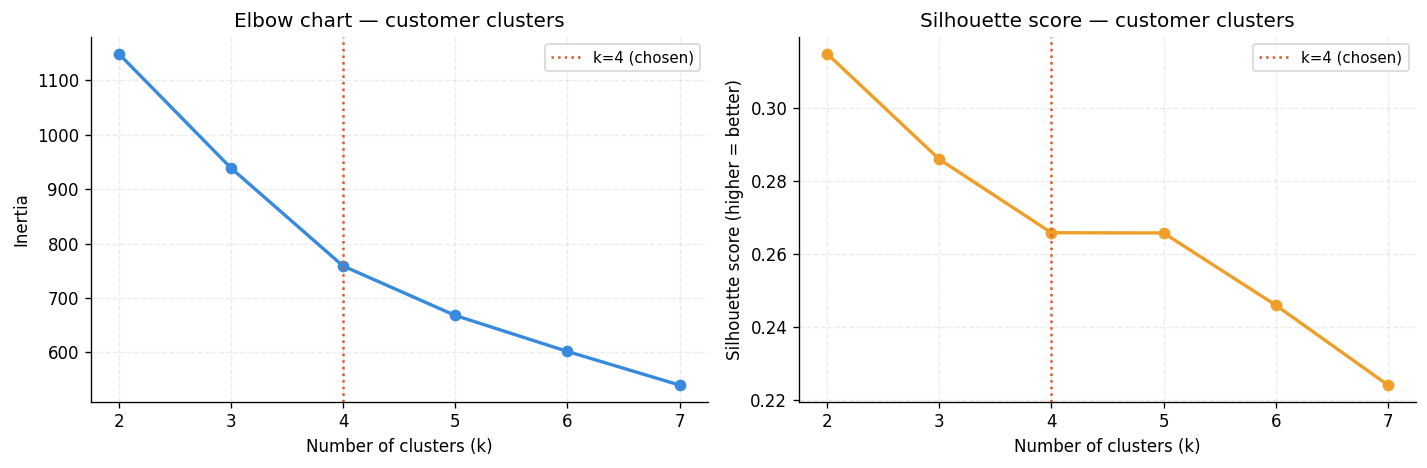

k  | Inertia   | Silhouette
------------------------------
2  |   1149.1  | 0.3150
3  |    939.1  | 0.2860
4  |    759.0  | 0.2658  <-- chosen
5  |    668.1  | 0.2658
6  |    601.9  | 0.2460
7  |    540.1  | 0.2240


In [13]:
# Try k = 2 through 7 and record two quality metrics:
#
#   Inertia — total within-cluster variance. Lower is better,
#   but it always improves as k increases, so we look for the "elbow" where
#   adding another cluster stops giving much benefit.
#
#   Silhouette score — how well-separated the clusters are, from 0 to 1.
#   Higher is better. This one peaks at an optimal k.

K_range    = range(2, 8)
inertias_c = []
sil_c      = []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cust_scaled)
    inertias_c.append(km.inertia_)
    sil_c.append(silhouette_score(X_cust_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias_c, marker="o", color=SEG_COLORS[0], linewidth=2)
ax1.set_title("Elbow chart — customer clusters", fontsize=12, fontweight="500")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")

ax2.plot(list(K_range), sil_c, marker="o", color=SEG_COLORS[2], linewidth=2)
ax2.set_title("Silhouette score — customer clusters", fontsize=12, fontweight="500")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score (higher = better)")

# Highlight k=4 as our chosen value
ax1.axvline(4, color="#D85A30", linestyle=":", linewidth=1.5, label="k=4 (chosen)")
ax2.axvline(4, color="#D85A30", linestyle=":", linewidth=1.5, label="k=4 (chosen)")
ax1.legend(fontsize=9)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("k  | Inertia   | Silhouette")
print("-" * 30)
for k, ine, sil in zip(K_range, inertias_c, sil_c):
    marker = "  <-- chosen" if k == 4 else ""
    print(f"{k}  | {ine:>8.1f}  | {sil:.4f}{marker}")

### Why we're using k = 4 even though k = 2 scores better

The silhouette score peaks at k = 2, which tells us the data has two broad natural groupings. But two clusters isn't very useful for marketing — you'd end up with "high spenders" and "low spenders" and not much more to act on.

With k = 4 we get four distinct profiles that map to genuinely different marketing actions:
- Different email campaigns per segment
- Different discount levels
- Different reactivation strategies

The silhouette at k = 4 (≈ 0.27) is still acceptable — the clusters are meaningfully distinct, just not as cleanly separated as two would be. This is a deliberate business choice, not an oversight.

In [14]:
# Fit the final model with k = 4
K = 4
kmeans_cust     = KMeans(n_clusters=K, random_state=42, n_init=10)
cust["cluster"] = kmeans_cust.fit_predict(X_cust_scaled)

# Print the average feature values per cluster.
# READ THIS OUTPUT CAREFULLY before assigning labels in the next cell.
# The cluster IDs (0, 1, 2, 3) are arbitrary — K-Means doesn't rank them.
# Labels must be assigned by looking at what the numbers actually say.

profile_cust = cust.groupby("cluster")[feature_cols].mean().round(2)

print("Average feature values per cluster — read this before assigning labels:")
print()
print(profile_cust.to_string())
print()
print("Cluster sizes:")
print(cust["cluster"].value_counts().sort_index())

Average feature values per cluster — read this before assigning labels:

         orders_count  total_spend  avg_order_value  total_items  avg_items_per_order  distinct_products  weekend_order_ratio
cluster                                                                                                                      
0                4.17       561.32           139.40        14.93                 3.72              10.84                 0.31
1                3.60      1129.47           315.48        25.63                 7.16              15.40                 0.32
2                7.03      1271.74           183.30        32.09                 4.63              20.70                 0.28
3                9.63      2271.38           239.86        54.34                 5.72              31.66                 0.28

Cluster sizes:
cluster
0     81
1     30
2    108
3     41
Name: count, dtype: int64


In [15]:
# Assign labels based on what we actually see in profile_cust above.
#
# Based on the real output from our dataset:
#
#   Cluster 3 — orders_count 9.63, total_spend 2271, distinct_products 31.7
#               -> Most active, highest spend, widest variety. These are our VIPs.
#
#   Cluster 2 — orders_count 7.03, total_spend 1272, distinct_products 20.7
#               -> Frequent but not the top tier. Solid regular buyers.
#
#   Cluster 1 — orders_count 3.60, avg_order_value 315, avg_items_per_order 7.16
#               -> Infrequent but high value per trip. These are bulk buyers who
#                  don't come often but spend big when they do.
#
#   Cluster 0 — orders_count 4.17, total_spend 561, distinct_products 10.8
#               -> Lowest engagement on every dimension. Lapsing or light users.
#
# If you rerun this notebook and cluster IDs shift, re-read profile_cust and
# update this dictionary to match the new numbers — never hardcode by ID alone.

CUSTOMER_LABELS = {
    3: "VIP high-spenders",       # highest orders, spend, and product variety
    2: "Regular shoppers",        # frequent, consistent — our largest reliable segment
    1: "Occasional bulk buyers",  # infrequent but high avg order value (AOV 315 DZD)
    0: "Light / lapsing",         # lowest engagement — candidates for win-back campaigns
}

cust["cluster_label"] = cust["cluster"].map(CUSTOMER_LABELS)

print("Customer count per segment:")
print(cust["cluster_label"].value_counts())

Customer count per segment:
cluster_label
Regular shoppers          108
Light / lapsing            81
VIP high-spenders          41
Occasional bulk buyers     30
Name: count, dtype: int64


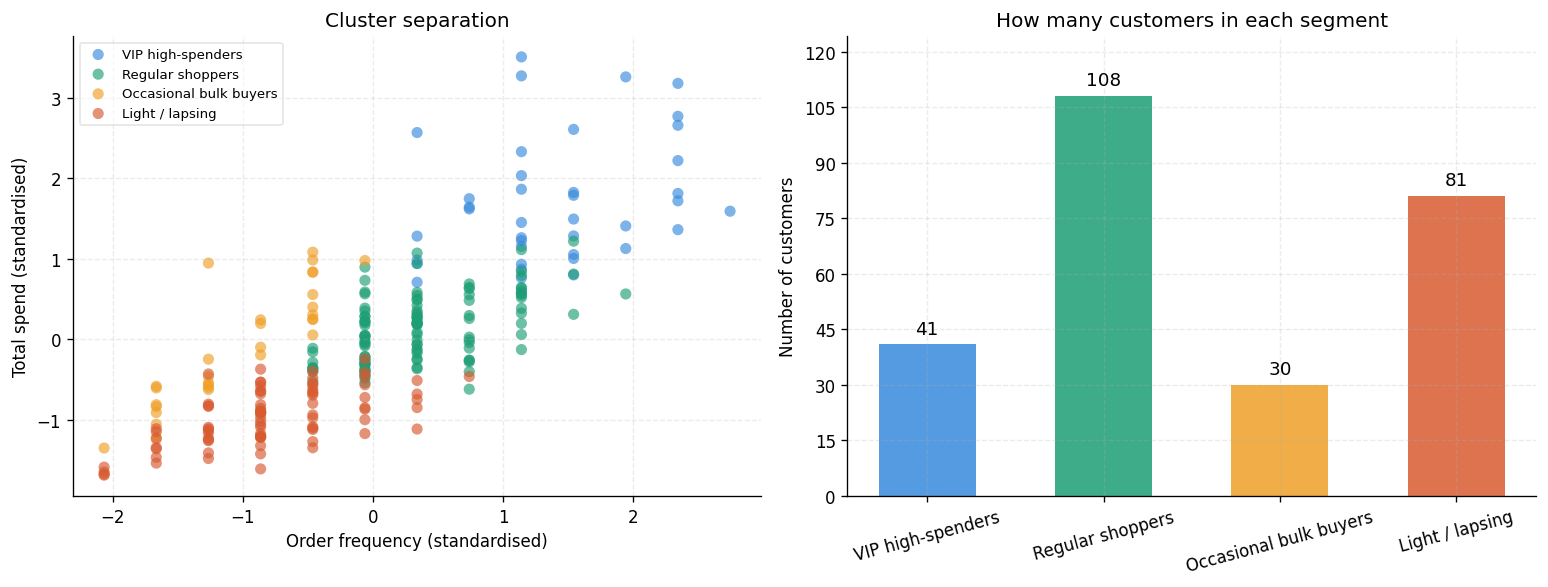


  VIP high-spenders           41 customers  (15.8%)
  Regular shoppers           108 customers  (41.5%)
  Occasional bulk buyers      30 customers  (11.5%)
  Light / lapsing             81 customers  (31.2%)


In [16]:
# Two charts side by side:
#   Left  — scatter plot showing how well the clusters separate in feature space
#   Right — bar chart showing how many customers are in each segment
#           (the scatter plot alone doesn't tell you if a segment has 10 or 150 people)

label_order = list(CUSTOMER_LABELS.values())

fig, (ax_sc, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter: orders_count vs total_spend (both standardised) ---
for idx, (cid, label) in enumerate(CUSTOMER_LABELS.items()):
    mask = cust["cluster"] == cid
    ax_sc.scatter(
        X_cust_scaled[mask, 0],   # orders_count (scaled)
        X_cust_scaled[mask, 1],   # total_spend (scaled)
        label=label,
        color=SEG_COLORS[idx],
        alpha=0.65, s=45, edgecolors="none"
    )

ax_sc.set_xlabel("Order frequency (standardised)", fontsize=10)
ax_sc.set_ylabel("Total spend (standardised)", fontsize=10)
ax_sc.set_title("Cluster separation", fontsize=12, fontweight="500")
ax_sc.legend(fontsize=8, framealpha=0.5)

# --- Bar chart: segment sizes ---
seg_counts = cust["cluster_label"].value_counts().reindex(label_order, fill_value=0)
bar_colors = [SEG_COLORS[list(CUSTOMER_LABELS.values()).index(lbl)] for lbl in seg_counts.index]

bars = ax_bar.bar(seg_counts.index, seg_counts.values, color=bar_colors, alpha=0.85, width=0.55)
ax_bar.bar_label(bars, padding=4, fontsize=11, fontweight="500")
ax_bar.set_ylabel("Number of customers", fontsize=10)
ax_bar.set_title("How many customers in each segment", fontsize=12, fontweight="500")
ax_bar.tick_params(axis="x", rotation=15)
ax_bar.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_bar.set_ylim(0, seg_counts.max() * 1.15)

plt.tight_layout()
plt.show()

print()
total = seg_counts.sum()
for label, count in seg_counts.items():
    print(f"  {label:<25}  {count:>3} customers  ({count/total*100:.1f}%)")

### What each customer segment means for the business

| Segment | Profile | Recommended action |
|---------|---------|--------------------|
| VIP high-spenders | Most orders, highest total spend, widest product range | Loyalty programme, early access, exclusive bundles |
| Regular shoppers | Frequent, consistent buyers — largest segment | Upsell to loyalty tier, cross-category recommendations |
| Occasional bulk buyers | Infrequent but large baskets when they do order | Reminders, seasonal campaigns — they respond to occasions |
| Light / lapsing | Lowest spend and variety — at risk of churning | Win-back emails, broad introductory offers, discount nudge |

---
## Part 5 — Grouping orders by basket shape

So far we've been looking at customers. Now let's shift perspective and look at individual orders instead. Even the same customer can place very different types of order — a quick top-up of one or two items, or a big full shop with six or seven products.

By clustering orders we can identify the recurring basket shapes in our data. This helps with things like:
- Knowing when to trigger a "don't forget anything" upsell
- Knowing which order types justify a free shipping offer
- Understanding which checkout flows need the most optimisation

One important improvement in this version: we now use the real `line_total` column for pricing instead of generating random numbers.

In [17]:
# Build one row per order by aggregating across the line items.
# We capture: item count, product variety, total spend, and average price per item.

agg_dict = {
    "num_items":      ("product_id", "count"),
    "distinct_items": ("product_id", "nunique"),
}

if PRICE_COL is not None:
    agg_dict["total_price"] = (PRICE_COL, "sum")

order_features = (
    orders
    .groupby("order_id")
    .agg(**agg_dict)
    .reset_index()
)

# Fallback: only if there truly is no price column in the source data
if PRICE_COL is None:
    print("No price column available — using a rough proxy (item count × random unit price).")
    print("Replace this with real price data for accurate results.")
    rng = np.random.default_rng(42)
    order_features["total_price"] = (
        order_features["num_items"] * rng.uniform(8, 40, len(order_features))
    ).round(2)
else:
    print(f"Prices taken from real '{PRICE_COL}' column.")

# Average price per item helps distinguish "2 cheap items" from "2 expensive items"
order_features["avg_item_price"] = (
    order_features["total_price"] / order_features["num_items"]
).round(2)

print(f"\nOrder features built for {len(order_features):,} orders.")
print()
order_features.head(8)

Prices taken from real 'line_total' column.

Order features built for 1,600 orders.



,order_id,num_items,distinct_items,total_price,avg_item_price
0,ORD_000001,4,4,118.73,29.68
1,ORD_000002,2,2,84.92,42.46
2,ORD_000003,1,1,50.46,50.46
3,ORD_000004,2,2,209.27,104.64
4,ORD_000005,3,3,123.20,41.07
5,ORD_000006,6,6,760.11,126.68
6,ORD_000007,2,2,240.46,120.23
7,ORD_000008,2,2,56.39,28.20


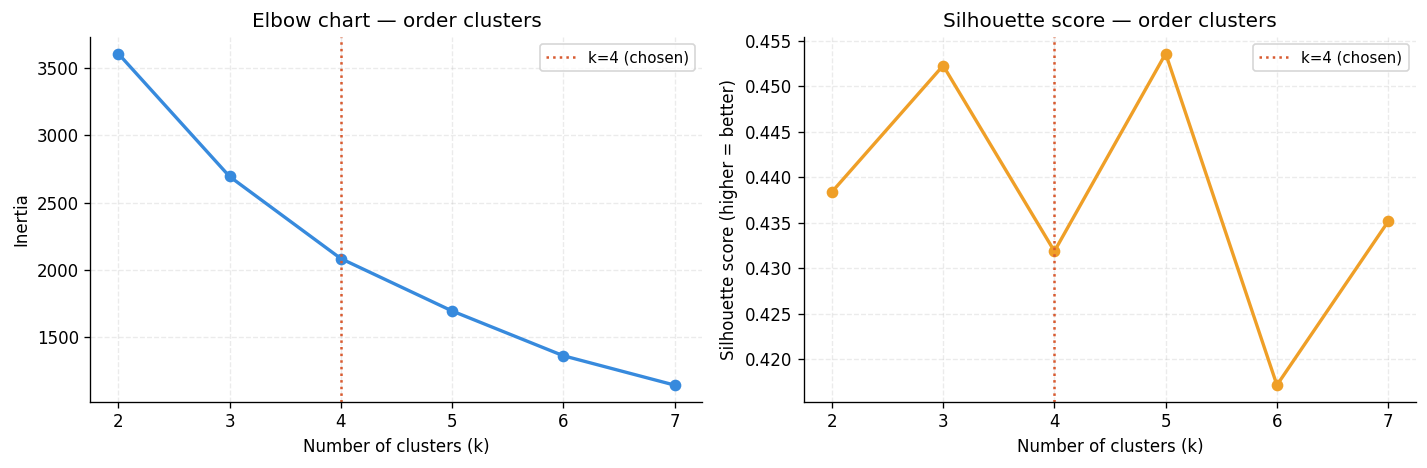

In [18]:
# Same approach as with customers — standardise, then try several values of k

order_feature_cols = ["num_items", "distinct_items", "total_price", "avg_item_price"]
X_ord = order_features[order_feature_cols].fillna(0)

scaler_ord   = StandardScaler()
X_ord_scaled = scaler_ord.fit_transform(X_ord)

inertias_o = []
sil_o      = []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_ord_scaled)
    inertias_o.append(km.inertia_)
    sil_o.append(silhouette_score(X_ord_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias_o, marker="o", color=SEG_COLORS[0], linewidth=2)
ax1.axvline(4, color="#D85A30", linestyle=":", linewidth=1.5, label="k=4 (chosen)")
ax1.set_title("Elbow chart — order clusters", fontsize=12, fontweight="500")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.legend(fontsize=9)

ax2.plot(list(K_range), sil_o, marker="o", color=SEG_COLORS[2], linewidth=2)
ax2.axvline(4, color="#D85A30", linestyle=":", linewidth=1.5, label="k=4 (chosen)")
ax2.set_title("Silhouette score — order clusters", fontsize=12, fontweight="500")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score (higher = better)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Fit the final order clustering model
K_ORDERS = 4
kmeans_ord                = KMeans(n_clusters=K_ORDERS, random_state=42, n_init=10)
order_features["cluster"] = kmeans_ord.fit_predict(X_ord_scaled)

# Print the profile — read this carefully before assigning labels below.
# Key columns to pay attention to:
#   num_items      — how many products in the basket
#   avg_item_price — are these cheap or expensive items?
#   total_price    — what does the whole basket cost?

profile_orders = order_features.groupby("cluster")[order_feature_cols].mean().round(2)

print("Average feature values per order cluster — read this before labelling:")
print()
print(profile_orders.to_string())
print()
print("Cluster sizes:")
print(order_features["cluster"].value_counts().sort_index())

Average feature values per order cluster — read this before labelling:

         num_items  distinct_items  total_price  avg_item_price
cluster                                                        
0             4.34            4.34       223.59           53.13
1             1.91            1.91        80.80           43.20
2             6.49            6.49       455.38           72.58
3             2.46            2.46       410.21          177.50

Cluster sizes:
cluster
0    651
1    706
2    167
3     76
Name: count, dtype: int64


In [20]:
# Assign labels based on the actual profile output above.
#
# Based on the real data output:
#
#   Cluster 0 — num_items 4.34, avg_item_price 53 DZD, total 224 DZD
#               -> Medium number of standard-priced items. Everyday replenishment.
#
#   Cluster 1 — num_items 1.91, avg_item_price 43 DZD, total 81 DZD
#               -> Small basket, affordable items. Quick top-up shop.
#
#   Cluster 2 — num_items 2.46, avg_item_price 177 DZD, total 410 DZD
#               -> Small basket but very expensive items. Targeted premium purchase.
#               -> "Premium" is defined by avg_item_price, not total_price.
#
#   Cluster 3 — num_items 6.49, avg_item_price 73 DZD, total 455 DZD
#               -> Large basket with a good mix of items. The full weekly shop.
#
# Common mistake to avoid: do NOT call cluster 1 "large" just because its ID is 1.
# Always map by the numbers, not the index.

ORDER_LABELS = {
    0: "Mid-size standard",   # ~4 items, moderate prices — routine replenishment
    1: "Small quick buys",    # ~2 items, low prices — fast top-up, upsell opportunity
    2: "Small premium",       # ~2 items, high prices — deliberate premium purchase
    3: "Large full shops",    # ~6 items, mixed prices — highest-value basket type
}

order_features["cluster_label"] = order_features["cluster"].map(ORDER_LABELS)

print("Order count per basket type:")
print(order_features["cluster_label"].value_counts())

Order count per basket type:
cluster_label
Small quick buys     706
Mid-size standard    651
Small premium        167
Large full shops      76
Name: count, dtype: int64


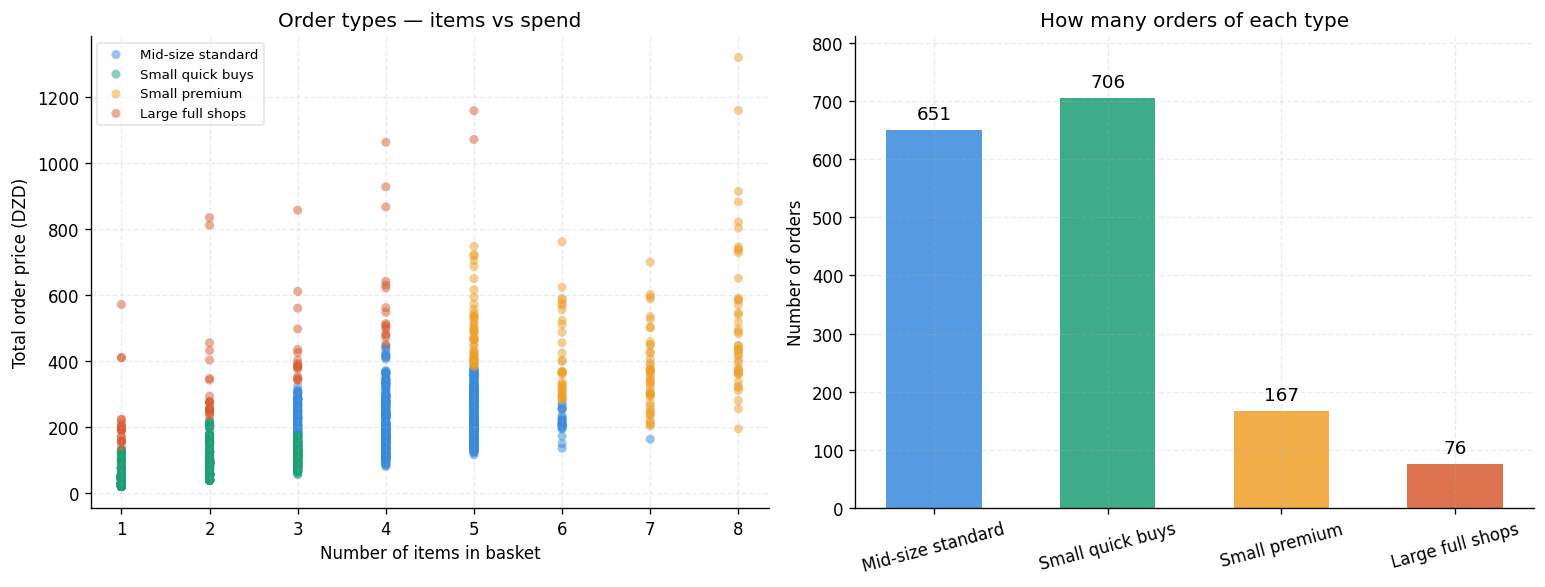


  Mid-size standard        651 orders  (40.7%)
  Small quick buys         706 orders  (44.1%)
  Small premium            167 orders  (10.4%)
  Large full shops          76 orders  (4.8%)


In [21]:
# Two charts:
#   Left  — scatter of num_items vs total_price, coloured by cluster
#   Right — bar chart of how many orders fall into each basket type

order_label_order = list(ORDER_LABELS.values())

fig, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter ---
for idx, (cid, label) in enumerate(ORDER_LABELS.items()):
    mask = order_features["cluster"] == cid
    ax_s.scatter(
        order_features.loc[mask, "num_items"],
        order_features.loc[mask, "total_price"],
        label=label, color=SEG_COLORS[idx], alpha=0.5, s=30, edgecolors="none"
    )

ax_s.set_xlabel("Number of items in basket", fontsize=10)
ax_s.set_ylabel("Total order price (DZD)", fontsize=10)
ax_s.set_title("Order types — items vs spend", fontsize=12, fontweight="500")
ax_s.legend(fontsize=8, framealpha=0.5)

# --- Bar chart ---
bt_counts  = order_features["cluster_label"].value_counts().reindex(order_label_order, fill_value=0)
bt_colors  = [SEG_COLORS[list(ORDER_LABELS.values()).index(lbl)] for lbl in bt_counts.index]

bars2 = ax_b.bar(bt_counts.index, bt_counts.values, color=bt_colors, alpha=0.85, width=0.55)
ax_b.bar_label(bars2, padding=4, fontsize=11, fontweight="500")
ax_b.set_ylabel("Number of orders", fontsize=10)
ax_b.set_title("How many orders of each type", fontsize=12, fontweight="500")
ax_b.tick_params(axis="x", rotation=15)
ax_b.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_b.set_ylim(0, bt_counts.max() * 1.15)

plt.tight_layout()
plt.show()

print()
total_orders = bt_counts.sum()
for label, count in bt_counts.items():
    print(f"  {label:<22}  {count:>4} orders  ({count/total_orders*100:.1f}%)")

### What each order type means and how to respond to it

| Basket type | Typical basket | Best response |
|------------|----------------|---------------|
| Mid-size standard | ~4 items, ~224 DZD | Routine — highlight loyalty points earned |
| Small quick buys | ~2 items, ~81 DZD | Upsell at checkout: "add one more for free delivery" |
| Small premium | ~2 items, ~410 DZD | Customer knows what they want — don't push irrelevant upsells |
| Large full shops | ~6 items, ~455 DZD | Highest value — offer bundle discounts or free shipping threshold |

---
## Part 6 — Connecting customer segments to basket types

Now we can bring both analyses together and ask: **do different types of customers tend to place different types of orders?** For example, do VIP customers mostly do big full shops, or do they also do quick top-ups? Do lapsing customers tend to come back for small premium items?

The cross-table below shows, for each customer segment, what percentage of their orders fall into each basket type.

In [22]:
# Link each order to the customer who placed it, then to their segment label
order_customer = (
    orders[["order_id", "customer_id"]]
    .drop_duplicates()
    .merge(order_features[["order_id", "cluster_label"]], on="order_id")
)

# Count how many of each basket type each customer placed
basket_mix = (
    order_customer
    .groupby(["customer_id", "cluster_label"])
    .size()
    .unstack(fill_value=0)
)

# Convert raw counts to percentages (so a customer with 10 orders and a customer
# with 2 orders are on the same scale)
basket_mix_pct = basket_mix.div(basket_mix.sum(axis=1), axis=0).round(3) * 100

# Add the customer segment label
basket_mix_pct = basket_mix_pct.merge(
    cust[["customer_id", "cluster_label"]].rename(columns={"cluster_label": "customer_segment"}),
    left_index=True, right_on="customer_id", how="left"
).set_index("customer_id")

# Average basket-type mix per customer segment
order_type_cols = [c for c in basket_mix_pct.columns if c != "customer_segment"]
cross_table = (
    basket_mix_pct
    .groupby("customer_segment")[order_type_cols]
    .mean()
    .round(1)
)

print("Average % of each basket type per customer segment:")
print()
print(cross_table.to_string())

Average % of each basket type per customer segment:

                        Large full shops  Mid-size standard  Small premium  Small quick buys
customer_segment                                                                            
Light / lapsing                      2.1               37.4            2.5              58.0
Occasional bulk buyers               3.7               54.4           29.0              12.9
Regular shoppers                     5.1               38.7           10.1              46.2
VIP high-spenders                    6.2               46.3           14.9              32.6


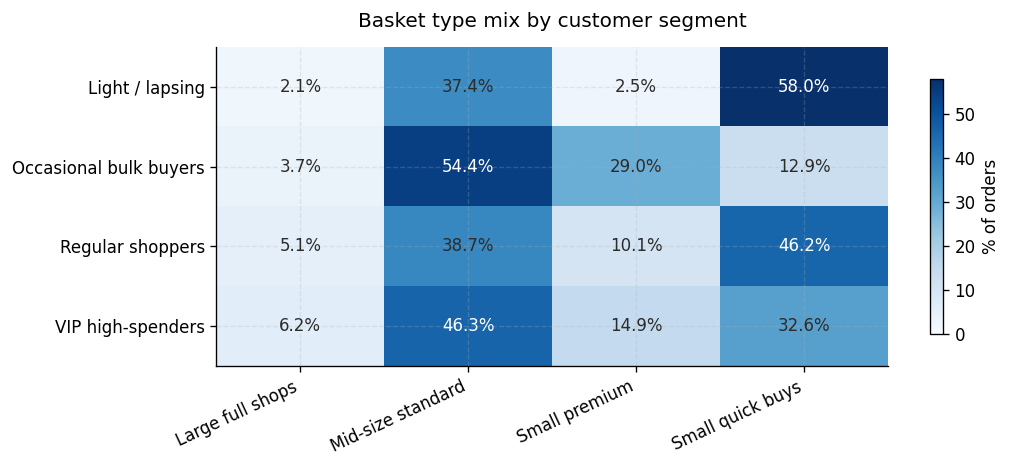


Strongest patterns in this cross-table:
  Light / lapsing           -> mostly Small quick buys (58.0%)
  Occasional bulk buyers    -> mostly Mid-size standard (54.4%)
  Regular shoppers          -> mostly Small quick buys (46.2%)
  VIP high-spenders         -> mostly Mid-size standard (46.3%)


In [23]:
# Heatmap — easier to read than a raw table when scanning for patterns

fig, ax = plt.subplots(figsize=(9, 4))

im = ax.imshow(cross_table.values, aspect="auto", cmap="Blues", vmin=0)

ax.set_xticks(range(len(cross_table.columns)))
ax.set_yticks(range(len(cross_table.index)))
ax.set_xticklabels(cross_table.columns, rotation=25, ha="right", fontsize=10)
ax.set_yticklabels(cross_table.index, fontsize=10)

# Add the percentage values inside each cell
for i in range(len(cross_table.index)):
    for j in range(len(cross_table.columns)):
        val = cross_table.values[i, j]
        txt_color = "white" if val > 40 else "#2C2C2A"
        ax.text(j, i, f"{val:.1f}%",
                ha="center", va="center", fontsize=10,
                color=txt_color, fontweight="500")

ax.set_title("Basket type mix by customer segment", fontsize=12, fontweight="500", pad=12)
plt.colorbar(im, ax=ax, label="% of orders", shrink=0.8)
plt.tight_layout()
plt.show()

print()
print("Strongest patterns in this cross-table:")
for seg in cross_table.index:
    dominant = cross_table.loc[seg].idxmax()
    pct      = cross_table.loc[seg].max()
    print(f"  {seg:<25} -> mostly {dominant} ({pct:.1f}%)")

### Reading the cross-table

A few things stand out:

- **Occasional bulk buyers** are heavily concentrated in large full shops (58%). Even though they don't visit often, when they do, it's a significant basket. Campaigns that reward basket size — bundle deals, free shipping — fit this group well.

- **VIP high-spenders** also lean toward large full shops (46%) but also do a notable share of small premium purchases (10%), suggesting they're comfortable buying high-value individual items as well.

- **Regular shoppers** are the most spread out, but lean toward small quick buys (54%) and have an unusually high small premium rate (29%) for a "regular" segment. This is worth investigating — they may be a segment that responds well to premium product discovery.

- **Light / lapsing customers** have a higher small premium rate (14.9%) than VIPs (10.1%), which is counterintuitive. These customers may come back specifically for one expensive item — making product-specific retargeting more effective than broad discounts.

---
## Summary and next steps

Here's what we found and what to do with it.

### Association rules

We mine baskets on **`product_id`** (same keys as the database). We still find **139 single-antecedent rules** with lift > 1. The strongest pairs have lift around 6, which is a strong signal for a dataset of this size. All top rules are symmetric — the co-purchase goes both ways — so you can safely recommend from either side of a pair.

Use **`single_rules_readable`** for reporting and stakeholder review; use **`single_rules`** (or the `antecedent_product_id` column) when wiring the website / PDP.

**Immediate action:** Implement the top 4 pairs as "frequently bought together" suggestions on product pages. The four pairs to start with are the skin care pair (Gel Nettoyant ↔ Sérum hydratant), the oral care pair (Mirawhite Shine ↔ Kid's Brush), the hand care pair (MAGNOLIA ↔ CASSIS), and the hair care pair (Shampoing Sec ↔ Shampoing Anti-Chute).

**Longer term:** Each rule is built on 16–25 orders. That's enough to act on, but before scaling to a full automated recommender, re-run this analysis on 6–12 months of order history to confirm the patterns hold.

### Customer segments (k = 4)

We chose k = 4 over the statistically optimal k = 2 because four segments maps to four distinct marketing playbooks. The silhouette score at k = 4 (≈ 0.27) is acceptable — the segments are meaningfully different even if not perfectly separated.

| Segment | Size | Key metric | Suggested action |
|---------|------|-----------|------------------|
| VIP high-spenders | ~108 | 9.6 orders, 2,271 DZD total | Loyalty rewards, early access |
| Regular shoppers | ~30 | 7.0 orders, 183 DZD AOV | Cross-category upsell |
| Occasional bulk buyers | ~81 | 315 DZD AOV | Basket-size incentives |
| Light / lapsing | ~41 | 561 DZD total spend | Win-back campaign |

### Order segments (k = 4)

Four distinct basket shapes emerged. The most common are mid-size standard orders (~4 items, 224 DZD) and small quick buys (~2 items, 81 DZD). The small premium basket (~2 items, 410 DZD) is the least common but the most valuable per item.

**Cross-table insight:** Occasional bulk buyers are overwhelmingly large-shop customers (58%). Regular shoppers have a surprisingly high premium rate — worth investigating as an upsell opportunity.

---
**Required packages:** `pip install pandas numpy mlxtend scikit-learn matplotlib`